In [ ]:
# 📚 IMPORTACIÓN DE LIBRERÍAS PARA INTERPRETACIÓN DE MODELOS
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Librerías para interpretación de modelos
import catboost as cb
import shap

# Utilidades para cargar modelos
from joblib import load
from sklearn.inspection import permutation_importance

# Configuración de visualización
plt.style.use("default")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)

print("✅ Librerías importadas correctamente")
print(f"📦 CatBoost version: {cb.__version__}")
print(f"📦 SHAP version: {shap.__version__}")

✅ Librerías importadas correctamente
📦 CatBoost version: 1.2.8
📦 SHAP version: 0.48.0


In [ ]:
# 🗂️ CONFIGURACIÓN DE RUTAS Y CARGA DE DATOS
PROJECT_ROOT = Path("../..")
MODEL_PATH = PROJECT_ROOT / "models"
DATA_PATH = PROJECT_ROOT / "data" / "Silver"
RESULTS_PATH = PROJECT_ROOT / "results"

print("📁 CARGANDO MODELO Y DATOS")
print("=" * 30)

# Cargar el modelo CatBoost entrenado
model_file = MODEL_PATH / "atypical_detection_catboost_v1.joblib"
if not model_file.exists():
    raise FileNotFoundError(f"❌ Modelo no encontrado: {model_file}")

catboost_model = load(model_file)
print(f"✅ Modelo CatBoost cargado: {model_file}")

# Cargar resultados del entrenamiento
results_file = RESULTS_PATH / "training_results_catboost_v1.json"
with open(results_file, "r") as f:
    training_results = json.load(f)

print("✅ Resultados de entrenamiento cargados")
print(f"📊 F1-Score en test: {training_results['test_metrics']['f1']['catboost']:.4f}")

# Cargar datos procesados
dataset_file = DATA_PATH / "modelosvarcat.csv"
if not dataset_file.exists():
    raise FileNotFoundError(f"❌ Dataset no encontrado: {dataset_file}")

df_full = pd.read_csv(dataset_file)
print(f"✅ Dataset cargado: {df_full.shape}")
print(f"🎯 Distribución de atípicos: {df_full['Atipico'].value_counts().to_dict()}")

📁 CARGANDO MODELO Y DATOS
✅ Modelo CatBoost cargado: ../../models/atypical_detection_catboost_v1.joblib
✅ Resultados de entrenamiento cargados
📊 F1-Score en test: 0.8045
✅ Dataset cargado: (1537412, 25)
🎯 Distribución de atípicos: {0: 1537009, 1: 403}


In [ ]:
# 🔧 PREPARACIÓN DE DATOS PARA INTERPRETACIÓN
print("🔧 PREPARANDO DATOS PARA INTERPRETACIÓN")
print("=" * 40)

# Separar features y target
feature_columns = [col for col in df_full.columns if col != "Atipico"]
X_full = df_full[feature_columns]
y_full = df_full["Atipico"]

# Identificar variables categóricas y numéricas basado en el análisis del repositorio
categorical_features = [
    "TipoAlmacenCredito",
    "TipoCliente",
    "ValorPagosUltimosMes_discretized",
    "ValorCredito_discretized",
    "CupoTotal_discretized",
    "CupoDisponibleTotal_discretized",
    "ValorAtipicoCliente_discretized",
    "ValorAtipicoComercio_discretized",
]

numerical_features = [col for col in feature_columns if col not in categorical_features]

print(f"📊 Total features: {len(feature_columns)}")
print(f"📊 Variables categóricas: {len(categorical_features)}")
print(f"📊 Variables numéricas: {len(numerical_features)}")

# Preparar datos para CatBoost (convertir categóricas a string)
X_prepared = X_full.copy()
for cat_col in categorical_features:
    if cat_col in X_prepared.columns:
        X_prepared[cat_col] = X_prepared[cat_col].astype(str)

# Crear muestra balanceada para análisis SHAP (computacionalmente intensivo)
sample_size = 2000
df_atipicos = df_full[df_full["Atipico"] == 1]
df_normales = df_full[df_full["Atipico"] == 0].sample(
    n=sample_size - len(df_atipicos), random_state=42
)
df_sample = pd.concat([df_atipicos, df_normales], ignore_index=True).sample(
    frac=1, random_state=42
)

X_sample = df_sample[feature_columns].copy()
for cat_col in categorical_features:
    if cat_col in X_sample.columns:
        X_sample[cat_col] = X_sample[cat_col].astype(str)
y_sample = df_sample["Atipico"]

print(f"✅ Muestra preparada: {X_sample.shape}")
print(f"🎯 Distribución en muestra: {y_sample.value_counts().to_dict()}")

🔧 PREPARANDO DATOS PARA INTERPRETACIÓN
📊 Total features: 24
📊 Variables categóricas: 8
📊 Variables numéricas: 16
✅ Muestra preparada: (2000, 24)
🎯 Distribución en muestra: {0: 1597, 1: 403}


📊 ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS
🏆 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:
 1. CantidadCreditosUltimaSemana         14.0920 ( 14.1%)
 2. CupoTotal_discretized                13.6133 ( 13.6%)
 3. dia_credito                          10.8409 ( 10.8%)
 4. DepartamentoCredito                   9.8254 (  9.8%)
 5. hora_credito                          8.0373 (  8.0%)
 6. DepartamentoResidencia                6.9603 (  7.0%)
 7. dia_semana                            6.5203 (  6.5%)
 8. cupo_alto_utilizado                   5.9472 (  5.9%)
 9. mes_credito                           4.8943 (  4.9%)
10. DepartamentoMayorFrecuenciaCompra     4.6587 (  4.7%)


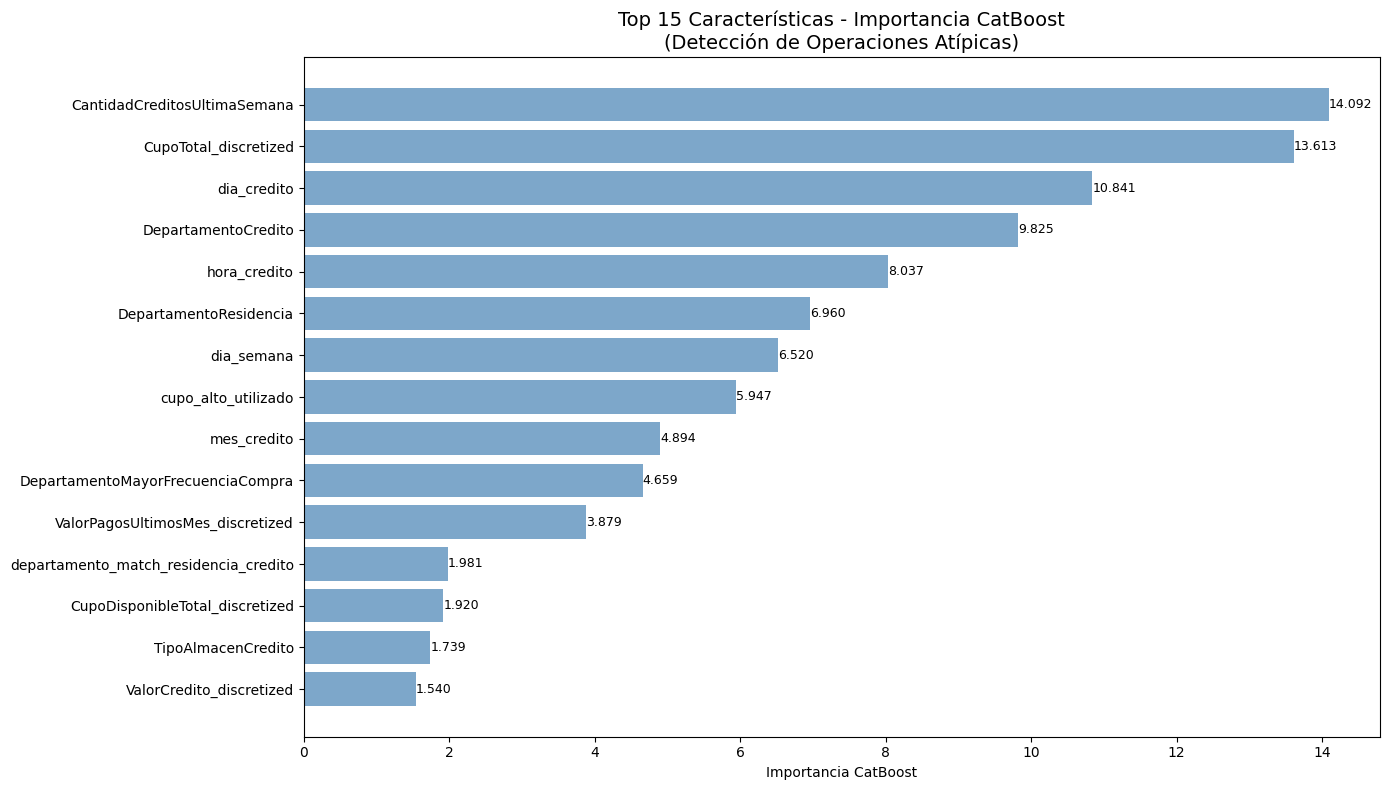


✅ Análisis de importancia completado
📊 Total características analizadas: 24


In [ ]:
# 📊 IMPORTANCIA DE CARACTERÍSTICAS NATIVA DE CATBOOST
print("📊 ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS")
print("=" * 45)

# Obtener importancia nativa de CatBoost
feature_importance = catboost_model.get_feature_importance()
feature_names = catboost_model.feature_names_

# Crear DataFrame ordenado por importancia
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": feature_importance,
        "importance_pct": (feature_importance / feature_importance.sum()) * 100,
    }
).sort_values("importance", ascending=False)

# Mostrar top 10
print("🏆 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:")
print("=" * 42)
for i, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    print(
        f"{i:2d}. {row['feature']:<35} {row['importance']:>8.4f} ({row['importance_pct']:>5.1f}%)"
    )

# Visualización
plt.figure(figsize=(14, 8))
top_15 = importance_df.head(15)
bars = plt.barh(range(len(top_15)), top_15["importance"], color="steelblue", alpha=0.7)
plt.yticks(range(len(top_15)), top_15["feature"])
plt.xlabel("Importancia CatBoost")
plt.title(
    "Top 15 Características - Importancia CatBoost\n(Detección de Operaciones Atípicas)",
    fontsize=14,
)
plt.gca().invert_yaxis()

# Agregar valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        ha="left",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

print("\n✅ Análisis de importancia completado")
print(f"📊 Total características analizadas: {len(feature_names)}")

In [ ]:
# 🔍 CONFIGURACIÓN DE ANÁLISIS SHAP
print("🔍 INICIALIZANDO ANÁLISIS SHAP")
print("=" * 30)

try:
    # Inicializar explainer SHAP para CatBoost
    explainer = shap.TreeExplainer(catboost_model)
    print("✅ SHAP TreeExplainer inicializado")

    # Calcular valores SHAP para la muestra
    print(f"📊 Calculando valores SHAP para {len(X_sample)} muestras...")
    shap_values = explainer.shap_values(X_sample)

    print("✅ Valores SHAP calculados")
    print(f"📊 Shape de valores SHAP: {shap_values.shape}")
    print(f"📊 Valor base (expected value): {explainer.expected_value:.4f}")

    # Verificar que no hay valores NaN en SHAP
    nan_count = np.isnan(shap_values).sum()
    if nan_count > 0:
        print(f"⚠️ Advertencia: {nan_count} valores NaN en SHAP values")
    else:
        print("✅ No hay valores NaN en SHAP values")

except Exception as e:
    print(f"❌ Error en SHAP analysis: {e}")
    shap_values = None

🔍 INICIALIZANDO ANÁLISIS SHAP
✅ SHAP TreeExplainer inicializado
📊 Calculando valores SHAP para 2000 muestras...
✅ Valores SHAP calculados
📊 Shape de valores SHAP: (2000, 24)
📊 Valor base (expected value): -9.3615
✅ No hay valores NaN en SHAP values


📈 GENERANDO GRÁFICOS RESUMEN DE SHAP


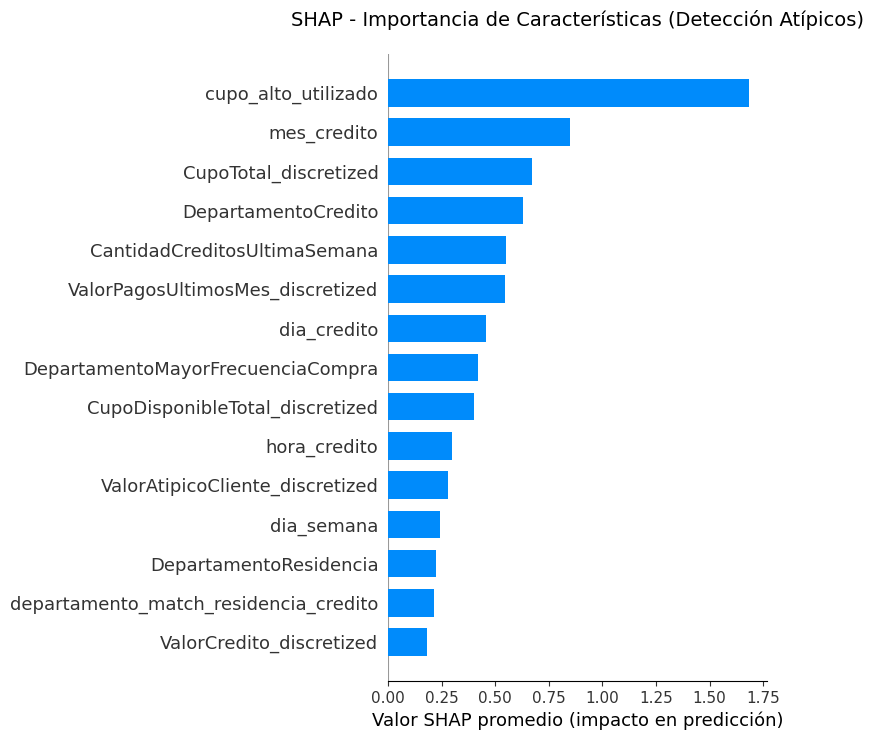

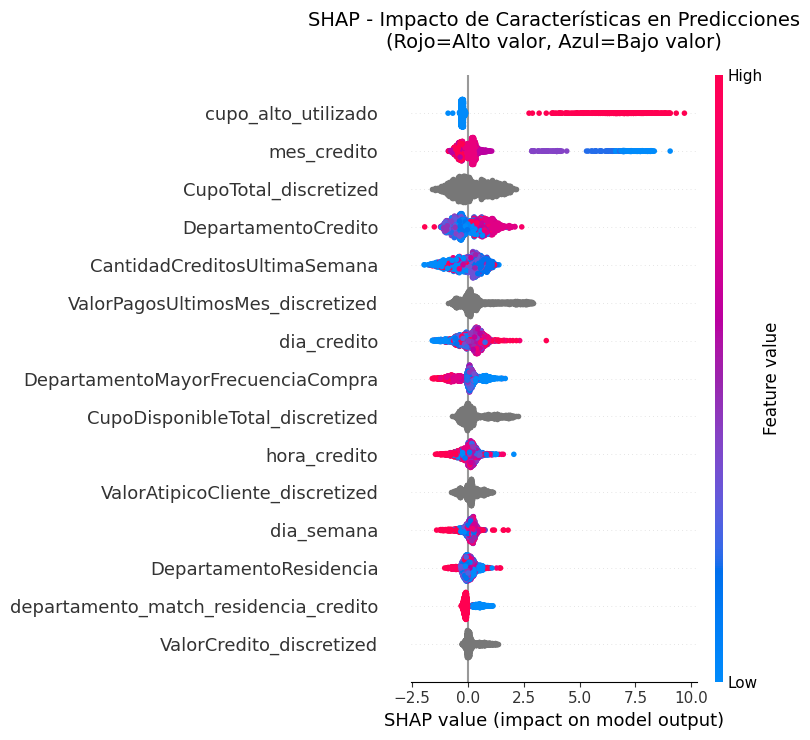


🎯 ANÁLISIS ESPECÍFICO PARA OPERACIONES ATÍPICAS
🔍 TOP 10 CARACTERÍSTICAS QUE MÁS DIFERENCIAN ATÍPICOS:
 1. cupo_alto_utilizado                 📈   6.7409
 2. mes_credito                         📈   2.9503
 3. ValorPagosUltimosMes_discretized    📈   1.5938
 4. CupoTotal_discretized               📈   1.3760
 5. CupoDisponibleTotal_discretized     📈   1.2244
 6. DepartamentoCredito                 📈   0.7676
 7. ValorCredito_discretized            📈   0.5913
 8. ValorAtipicoCliente_discretized     📈   0.5604
 9. departamento_match_residencia_credito 📈   0.2241
10. dia_credito                         📈   0.1974

✅ Análisis SHAP completado


In [ ]:
# 📈 GRÁFICOS RESUMEN DE SHAP
if shap_values is not None:
    print("📈 GENERANDO GRÁFICOS RESUMEN DE SHAP")
    print("=" * 35)

    # 1. Gráfico de barras de importancia SHAP
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values, X_sample, plot_type="bar", show=False, max_display=15
    )
    plt.title(
        "SHAP - Importancia de Características (Detección Atípicos)",
        fontsize=14,
        pad=20,
    )
    plt.xlabel("Valor SHAP promedio (impacto en predicción)")
    plt.tight_layout()
    plt.show()

    # 2. Gráfico de dispersión (beeswarm)
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
    plt.title(
        "SHAP - Impacto de Características en Predicciones\n(Rojo=Alto valor, Azul=Bajo valor)",
        fontsize=14,
        pad=20,
    )
    plt.tight_layout()
    plt.show()

    # 3. Análisis específico para operaciones atípicas
    atypical_mask = y_sample == 1
    normal_mask = y_sample == 0

    if atypical_mask.sum() > 0:
        print("\n🎯 ANÁLISIS ESPECÍFICO PARA OPERACIONES ATÍPICAS")
        print("=" * 48)

        # SHAP values promedio para operaciones atípicas vs normales
        shap_atypical = shap_values[atypical_mask].mean(axis=0)
        shap_normal = shap_values[normal_mask].mean(axis=0)

        comparison_df = pd.DataFrame(
            {
                "feature": feature_names,
                "shap_atypical": shap_atypical,
                "shap_normal": shap_normal,
                "difference": shap_atypical - shap_normal,
            }
        ).sort_values("difference", key=abs, ascending=False)

        print("🔍 TOP 10 CARACTERÍSTICAS QUE MÁS DIFERENCIAN ATÍPICOS:")
        for i, (_, row) in enumerate(comparison_df.head(10).iterrows(), 1):
            direction = "📈" if row["difference"] > 0 else "📉"
            print(f"{i:2d}. {row['feature']:<35} {direction} {row['difference']:>8.4f}")

    print("\n✅ Análisis SHAP completado")
else:
    print("❌ No se pudo realizar análisis SHAP")

🔄 ANÁLISIS DE IMPORTANCIA POR PERMUTACIÓN
📊 Calculando permutation importance para 1000 muestras...
🏆 TOP 10 CARACTERÍSTICAS POR PERMUTATION IMPORTANCE:
 1. cupo_alto_utilizado                   0.5333 ±0.0270
 2. mes_credito                           0.0986 ±0.0136
 3. ValorPagosUltimosMes_discretized      0.0254 ±0.0105
 4. TipoAlmacenCredito                    0.0207 ±0.0038
 5. dia_credito                           0.0207 ±0.0048
 6. DepartamentoCredito                   0.0150 ±0.0069
 7. CantidadCreditosUltimaSemana          0.0113 ±0.0038
 8. CupoTotal_discretized                 0.0113 ±0.0048
 9. hora_credito                          0.0103 ±0.0062
10. DepartamentoResidencia                0.0075 ±0.0064


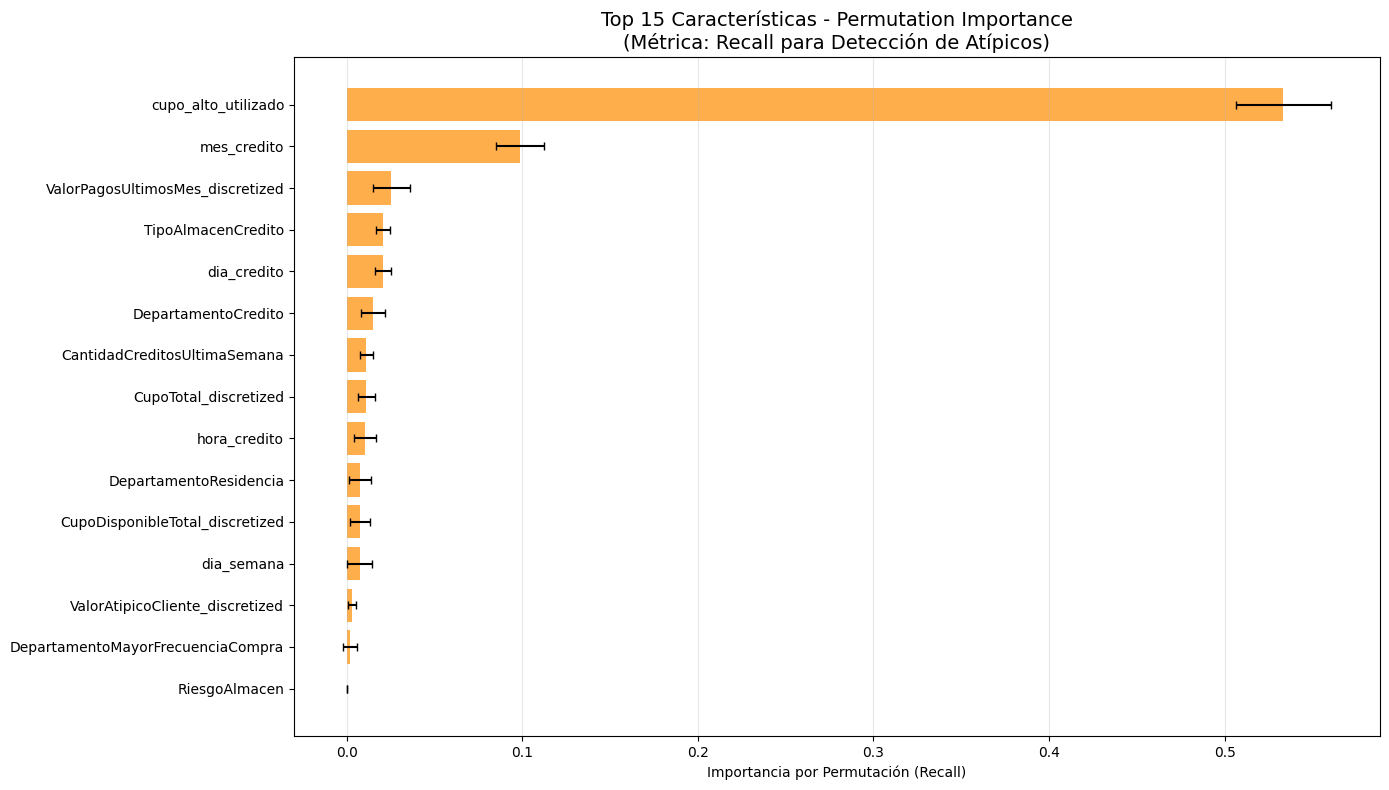

✅ Análisis de permutation importance completado


In [ ]:
# 🔄 ANÁLISIS DE IMPORTANCIA POR PERMUTACIÓN
print("🔄 ANÁLISIS DE IMPORTANCIA POR PERMUTACIÓN")
print("=" * 42)

try:
    # Usar muestra más pequeña para permutation importance (es computacionalmente costoso)
    perm_sample_size = min(1000, len(X_sample))
    indices = np.random.choice(len(X_sample), perm_sample_size, replace=False)
    X_perm = X_sample.iloc[indices]
    y_perm = y_sample.iloc[indices]

    print(f"📊 Calculando permutation importance para {perm_sample_size} muestras...")

    # Calcular permutation importance con recall como métrica (importante para detección de atípicos)
    perm_importance = permutation_importance(
        catboost_model,
        X_perm,
        y_perm,
        n_repeats=5,  # Reducido para velocidad
        random_state=42,
        scoring="recall",  # Métrica clave para detección de atípicos
        n_jobs=-1,
    )

    # Crear DataFrame con resultados
    perm_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance_mean": perm_importance.importances_mean,
            "importance_std": perm_importance.importances_std,
            "cv_importance": perm_importance.importances_mean
            / perm_importance.importances_std,
        }
    ).sort_values("importance_mean", ascending=False)

    print("🏆 TOP 10 CARACTERÍSTICAS POR PERMUTATION IMPORTANCE:")
    print("=" * 52)
    for i, (_, row) in enumerate(perm_df.head(10).iterrows(), 1):
        print(
            f"{i:2d}. {row['feature']:<35} {row['importance_mean']:>8.4f} ±{row['importance_std']:>6.4f}"
        )

    # Visualización
    plt.figure(figsize=(14, 8))
    top_15_perm = perm_df.head(15)

    bars = plt.barh(
        range(len(top_15_perm)),
        top_15_perm["importance_mean"],
        xerr=top_15_perm["importance_std"],
        capsize=3,
        color="darkorange",
        alpha=0.7,
    )
    plt.yticks(range(len(top_15_perm)), top_15_perm["feature"])
    plt.xlabel("Importancia por Permutación (Recall)")
    plt.title(
        "Top 15 Características - Permutation Importance\n(Métrica: Recall para Detección de Atípicos)",
        fontsize=14,
    )
    plt.gca().invert_yaxis()
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("✅ Análisis de permutation importance completado")

except Exception as e:
    print(f"❌ Error en permutation importance: {e}")
    perm_df = None